# Partie 1 - Analyse Exploratoire des Donnees

Ce notebook documente l'exploration initiale du dataset RH : structure, qualite des donnees, distributions, premiers signaux sur l'attrition et variables potentiellement utiles pour la suite du projet.


In [14]:
from pathlib import Path
import importlib
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import hr_analysis_utils as utils
importlib.reload(utils)

MahalanobisAnomalyDetector = utils.MahalanobisAnomalyDetector
random_oversample_minority = utils.random_oversample_minority
SimpleLogisticRegression = utils.SimpleLogisticRegression
attrition_by_group = utils.attrition_by_group
attrition_gap_summary = utils.attrition_gap_summary
coefficient_importance = utils.coefficient_importance
correlation_with_attrition = utils.correlation_with_attrition
dataset_overview = utils.dataset_overview
kpi_table = utils.kpi_table
load_data = utils.load_data
missing_summary = utils.missing_summary
numeric_summary = utils.numeric_summary
plot_bar = utils.plot_bar
plot_box_by_attrition = utils.plot_box_by_attrition
plot_correlation_heatmap = utils.plot_correlation_heatmap
plot_histogram = utils.plot_histogram
plot_top_coefficients = utils.plot_top_coefficients
prepare_model_data = utils.prepare_model_data
prepare_numeric_anomaly_data = utils.prepare_numeric_anomaly_data
pr_auc_score_manual = utils.pr_auc_score_manual
roc_auc_score_manual = utils.roc_auc_score_manual
salary_gap_by_gender = utils.salary_gap_by_gender
average_by_group = utils.average_by_group
top_attrition_segments = utils.top_attrition_segments
find_best_threshold = utils.find_best_threshold
classification_metrics = utils.classification_metrics

DATA_PATH = PROJECT_ROOT / "raw" / "people_analytics_dataset.csv"
df = load_data(DATA_PATH)
pd.set_option("display.max_columns", 100)


## 1. Chargement et vue d'ensemble

On commence par verifier la taille du dataset, le taux d'attrition et la presence de donnees manquantes.


In [15]:
dataset_overview(df)


,Indicateur,Valeur
0,Nombre de lignes,8020.00
1,Variables sources,28.00
2,Variables ajoutees,6.00
3,Taux d'attrition (%),2.59
4,Cellules manquantes (source),482.00
5,employee_id dupliques,20.00


In [16]:
df.head()


,employee_id,age,gender,country,department,job_role,education_level,school_tier,parental_status,accented_name_flag,contracted_hours_weekly,years_at_company,manager_level,remote_ratio,performance_rating,engagement_score,training_hours,internal_mobility_count,promotion_last_3y,absenteeism_days,overtime_hours,manager_favoritism_score,visibility_score,psychological_safety_score,salary,bonus,stock_options,attrition,age_group,remote_band,engagement_band,overtime_band,absence_band,salary_quartile
0,EMP_100000,25,Male,Canada,Data,Data Scientist,Master,Tier 2,Parent,0,35,4,0,0,2.993385,60.122453,24,1,0,1,5,68.1,62.7,56.376963,73993.0,5242,202,0,<30,0%,Medium,0-5,0-2,Q4
1,EMP_100001,23,Male,Germany,Sales,Sales Executive,PhD,Tier 3,No Children,0,35,0,0,100,3.662989,67.797542,15,0,1,10,3,61.1,39.3,57.818140,56181.0,6709,514,0,<30,100%,Medium,0-5,6-10,Q2
2,EMP_100002,34,Male,France,HR,Talent Manager,Master,Tier 2,No Children,0,35,4,0,25,2.926155,77.175144,53,1,0,10,0,76.0,64.8,67.896167,57278.0,1887,2504,0,30-39,25%,High,0-5,6-10,Q2
3,EMP_100003,38,Male,France,Data,Data Engineer,Master,Tier 2,No Children,0,28,10,0,75,3.956917,46.718743,53,2,0,4,26,62.9,55.3,69.214483,82949.0,7407,943,0,30-39,75%,Low,26+,3-5,Q4
4,EMP_100004,48,Female,Germany,IT,DevOps Engineer,Bachelor,Tier 2,No Children,1,28,6,2,50,1.541377,73.182769,27,0,1,8,28,39.8,65.0,77.639587,82354.0,1567,6782,0,40-49,50%,High,26+,6-10,Q4


## 2. Variables et qualite de donnees

Le CSV reel contient 28 variables. Par rapport a l'enonce initial, on note notamment la presence de `years_at_company` et `accented_name_flag`, tandis que `salary_band` n'est pas present.


In [17]:
missing_summary(df)


,missing_count,missing_pct,dtype
performance_rating,161,2.01,float64
engagement_score,161,2.01,float64
salary,160,2.00,float64


In [18]:
numeric_summary(df).head(15)


,mean,std,min,25%,50%,75%,max
age,35.84,8.42,22.0,30.00,36.00,42.00,63.0
accented_name_flag,0.20,0.40,0.0,0.00,0.00,0.00,1.0
contracted_hours_weekly,32.94,3.19,28.0,28.00,35.00,35.00,35.0
years_at_company,5.05,4.06,0.0,1.00,5.00,8.00,25.0
manager_level,0.50,0.79,0.0,0.00,0.00,1.00,3.0
remote_ratio,50.73,31.16,0.0,25.00,50.00,75.00,100.0
performance_rating,3.46,0.70,1.0,2.99,3.46,3.94,5.0
engagement_score,68.15,14.92,20.0,58.12,68.08,78.48,100.0
training_hours,34.64,17.70,0.0,22.00,34.00,47.00,104.0
internal_mobility_count,1.01,1.00,0.0,0.00,1.00,2.00,7.0


## 3. Distribution de la cible

L'attrition est tres desequilibree : environ 2,6 % des collaborateurs quittent l'entreprise. Cette caracteristique aura un impact direct sur l'evaluation du modele.


In [19]:
attrition_table = attrition_by_group(df, "attrition", ascending=True)
attrition_table


,attrition,effectif,departs,attrition_rate_pct
0,0,7812,0,0.0
1,1,208,208,100.0


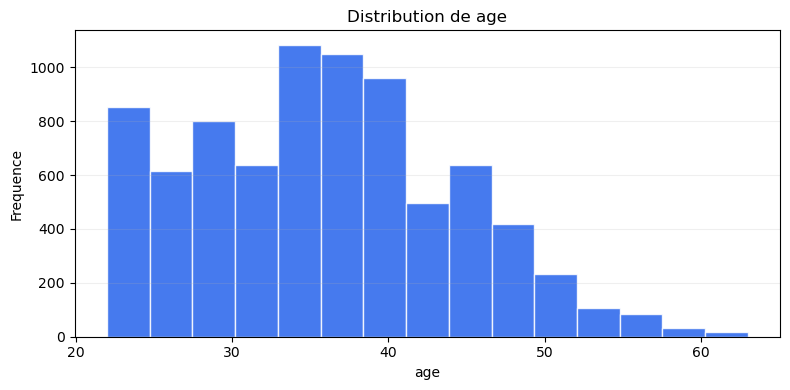

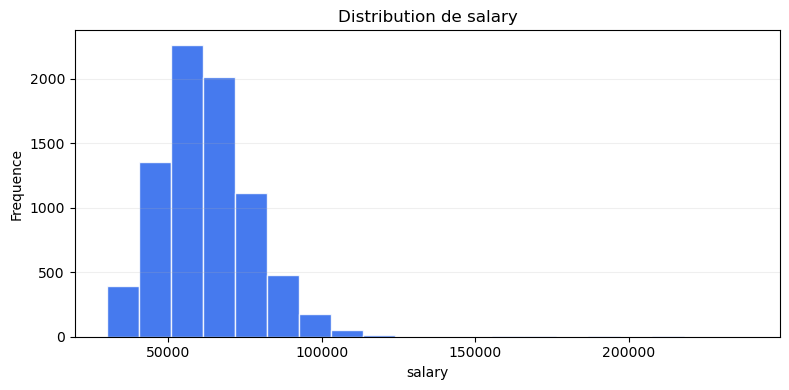

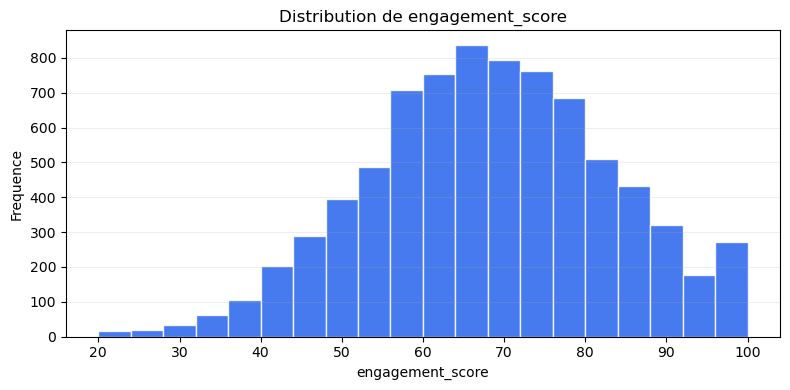

In [20]:
plot_histogram(df, "age", bins=15)
plot_histogram(df, "salary", bins=20)
plot_histogram(df, "engagement_score", bins=20)


## 4. Premiers signaux par segment

Cette section cherche a identifier les segments ou le turnover semble plus eleve, avant toute modelisation.


In [21]:
attrition_department = attrition_by_group(df, "department")
attrition_country = attrition_by_group(df, "country")
attrition_remote = attrition_by_group(df, "remote_band", ascending=True)

display(attrition_department)
display(attrition_country)
display(attrition_remote)


,department,effectif,departs,attrition_rate_pct
4,IT,970,28,2.89
0,Customer Support,1027,29,2.82
2,Finance,950,26,2.74
7,Sales,1005,27,2.69
3,HR,1036,27,2.61
5,Marketing,972,25,2.57
1,Data,1042,25,2.40
6,Operations,1018,21,2.06


,country,effectif,departs,attrition_rate_pct
1,France,1338,51,3.81
5,USA,1347,37,2.75
4,UK,1342,36,2.68
2,Germany,1356,36,2.65
0,Canada,1356,26,1.92
3,Spain,1281,22,1.72


,remote_band,effectif,departs,attrition_rate_pct
1,100%,1194,25,2.09
0,0%,1236,31,2.51
3,50%,2843,72,2.53
2,25%,1215,32,2.63
4,75%,1532,48,3.13


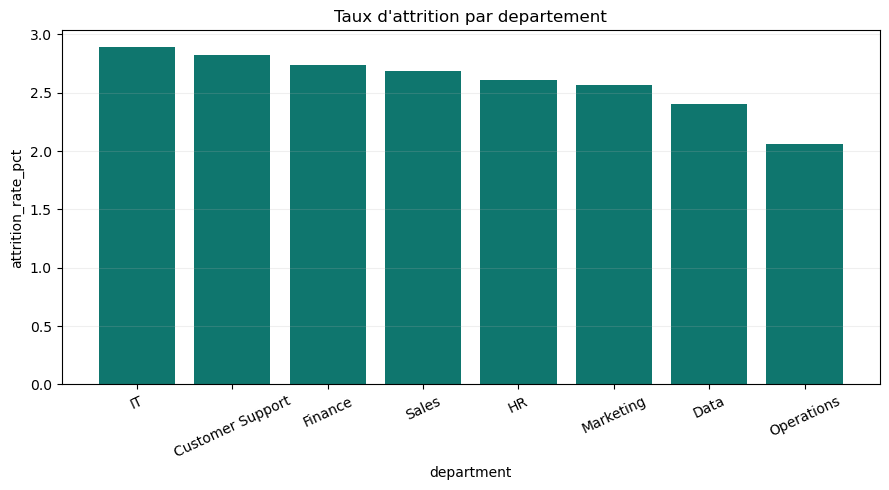

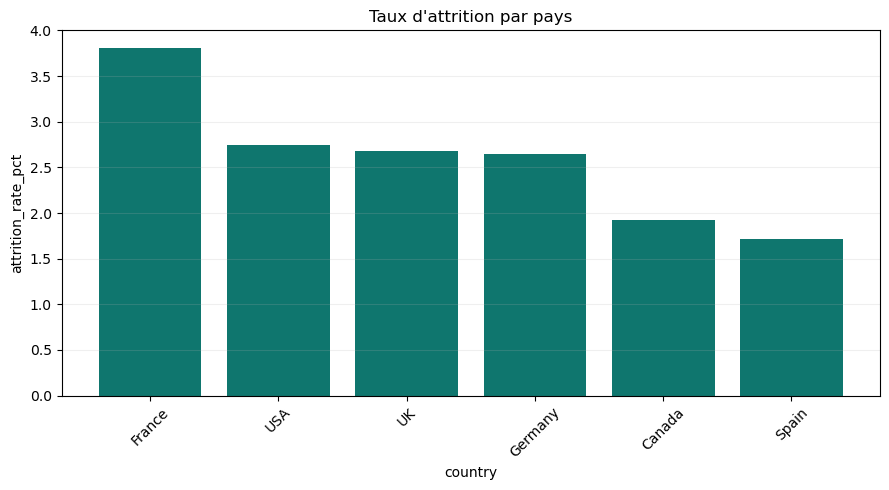

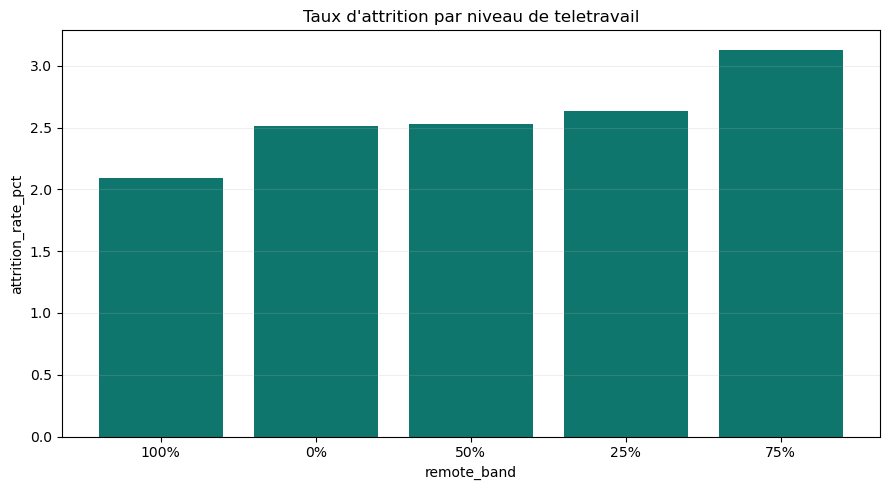

In [22]:
plot_bar(attrition_department, "department", "attrition_rate_pct", title="Taux d'attrition par departement", rotation=25)
plot_bar(attrition_country, "country", "attrition_rate_pct", title="Taux d'attrition par pays")
plot_bar(attrition_remote, "remote_band", "attrition_rate_pct", title="Taux d'attrition par niveau de teletravail", rotation=0)


## 5. Variables numeriques et attrition

On compare ensuite plusieurs dimensions RH entre les collaborateurs restes et ceux ayant quitte l'entreprise.


In [23]:
attrition_gap_summary(df)


,depart_mean,reste_mean,ecart_depart_moins_reste
engagement_score,66.92,68.18,-1.26
psychological_safety_score,64.57,66.23,-1.66
overtime_hours,20.44,19.52,0.92
absenteeism_days,7.81,6.90,0.91
training_hours,32.36,34.71,-2.35
salary,60794.27,62353.96,-1559.68
visibility_score,64.76,64.92,-0.16
manager_favoritism_score,60.77,60.54,0.23
years_at_company,4.93,5.05,-0.12
internal_mobility_count,0.96,1.01,-0.05


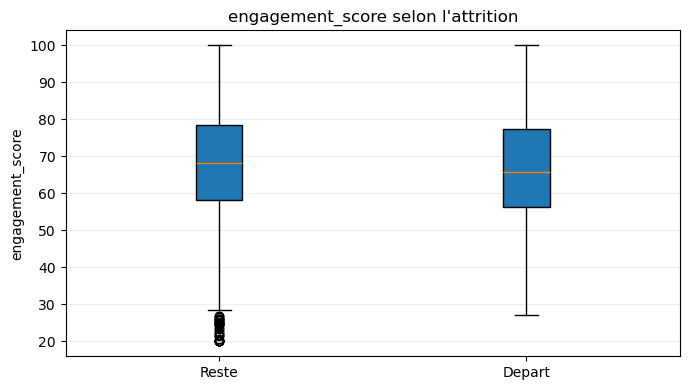

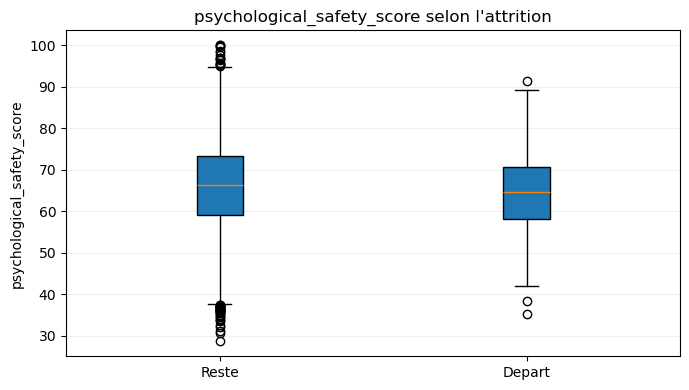

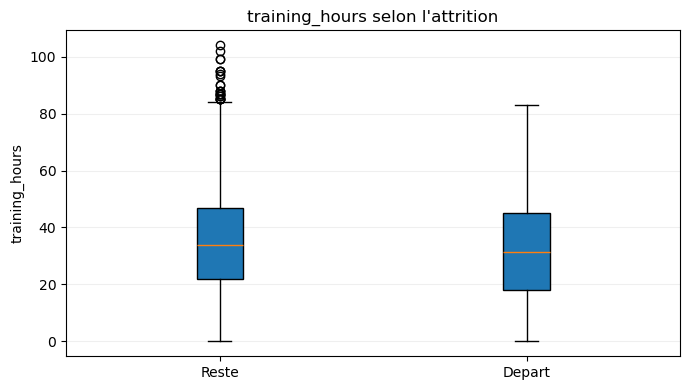

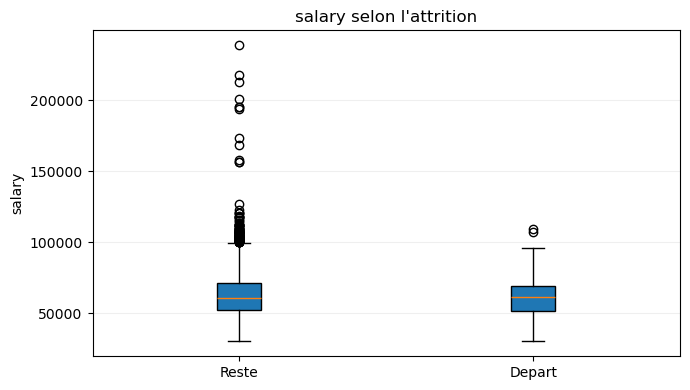

In [24]:
plot_box_by_attrition(df, "engagement_score")
plot_box_by_attrition(df, "psychological_safety_score")
plot_box_by_attrition(df, "training_hours")
plot_box_by_attrition(df, "salary")


In [25]:
correlation_with_attrition(df)


attrition                     1.000
absenteeism_days              0.030
accented_name_flag            0.015
overtime_hours                0.012
promotion_last_3y             0.007
performance_rating            0.004
manager_favoritism_score      0.003
remote_ratio                 -0.001
visibility_score             -0.003
manager_level                -0.004
age                          -0.004
bonus                        -0.005
stock_options                -0.005
years_at_company             -0.005
internal_mobility_count      -0.008
engagement_score             -0.013
salary                       -0.016
training_hours               -0.021
psychological_safety_score   -0.025
contracted_hours_weekly      -0.046
Name: attrition, dtype: float64

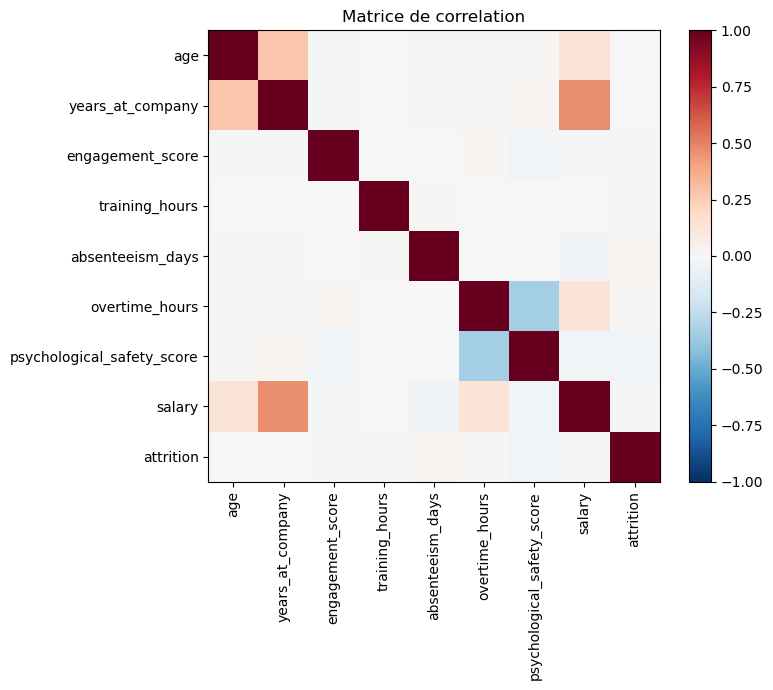

In [26]:
plot_correlation_heatmap(
    df,
    columns=[
        "age",
        "years_at_company",
        "engagement_score",
        "training_hours",
        "absenteeism_days",
        "overtime_hours",
        "psychological_safety_score",
        "salary",
        "attrition",
    ],
    figsize=(9, 7),
)


## 6. Faits marquants EDA

- Le dataset couvre **8 020 collaborateurs** et presente un **taux d'attrition faible (2,59 %)**.
- Les principales valeurs manquantes concernent `performance_rating`, `engagement_score` et `salary`, mais dans des proportions limitees.
- Les pays et departements ne sont pas exposes de maniere uniforme : **la France** et **le departement IT** figurent parmi les zones les plus touchees par l'attrition.
- Les collaborateurs partis montrent en moyenne un **engagement plus bas**, une **securite psychologique plus faible**, **moins de formation**, et un peu plus d'absence et d'heures supplementaires.
- Les correlations lineaires avec l'attrition restent faibles, ce qui suggere un signal predictif modere et potentiellement diffus.
